# 16 · 패턴: 체인지로그 작성기

**패턴:** 체인지로그 작성기(changelog drafter).

> "항목을 표준 섹션으로 묶는다 — Features, Bug Fixes, Performance, Breaking Changes, Security, Documentation, Internal. 작성기는 절대 게시하지 않는다. 제안할 뿐이다."

**문제 설정** — 릴리스 노트를 초안하려면 루프가 두 가지 일을 연달아 해야 한다.

- 병합된 커밋 하나하나를 유형으로 분류한다(feature, fix, refactor, performance, ...).
- 그 유형을 재료로 삼아 깔끔하게 묶인 노트를 쓴다.

앞의 단계는 채점할 수 있고 뒤의 단계는 눈으로 봐야 한다. 그래서 이 노트북은 **분류기를 실제 커밋 위에서 숫자로 재고, 그 결과로 모델이 노트를 초안하는 과정을 그대로 보여 준다.**

**벤치마크** — Vue 코어 저장소에서 캔 실제 conventional commit 3500건 이상. 정답 라벨은 사람이 따로 붙인 것이 아니라 **저자가 커밋할 때 직접 타이핑한 접두사**다(feat/fix/docs/refactor/perf/test/build/ci/chore). 모델에게는 그 접두사를 지운 메시지만 주고 유형을 복원하게 한다. 다수결 베이스라인과 나란히 놓고 정확도와 macro-F1 으로 채점한 다음, 분류 결과로 체인지로그를 초안하게 한다.

**미리 밝혀 두는 경계** — 이 노트북은 릴리스 노트를 자동으로 게시하는 루프를 만들지 않는다. 만드는 것은 **사람이 손볼 초안**이다. 분류기의 성적이 그 선에서 멈춰야 한다고 말하고, 왜 그런지가 마지막 두 절의 주제다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================


*병합된 커밋을 분류한 다음, 사람 승인을 전제로 묶인 릴리스 노트를 초안한다*

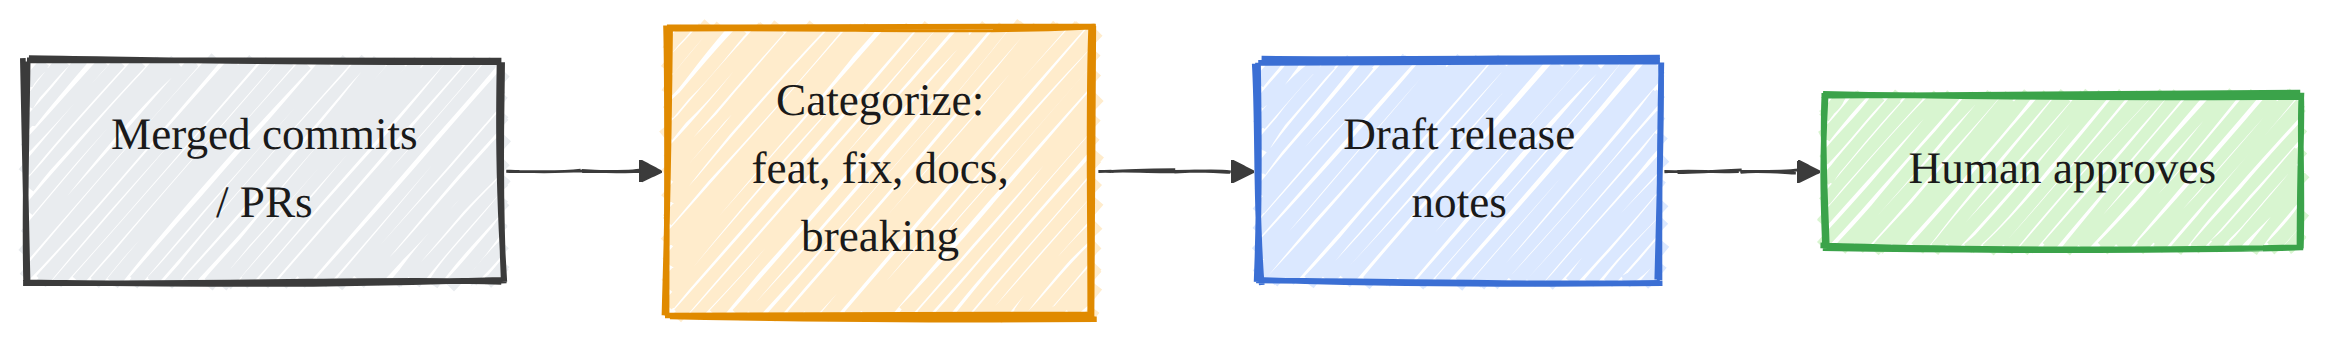

데이터가 없다: /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data/commits.json
  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 commits.json 을 내려받는다.
  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).
  사용 가능한 커밋:                 360
  분류 표본:                     108
  타입:                        ['build', 'chore', 'ci', 'docs', 'feat', 'fix', 'perf', 'refactor', 'test']
  데이터 출처:                    synthetic-fallback


In [1]:
import os
import sys
import json
import random
import collections

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, plotting, runlog, runtime
from common.llm import LLM

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.diagram("changelog", "병합된 커밋을 분류한 다음, 사람 승인을 전제로 묶인 릴리스 노트를 초안한다")

# ── 데이터 경로 ───────────────────────────────────────────────────
# 한국어판 수정: 원본은 /ephemeral/hf/commits.json 을 절대경로로 박아 뒀다.
# 그 경로는 원저자의 GPU 서버에만 존재하므로 다른 환경에서는 첫 셀이 곧바로
# FileNotFoundError 로 죽는다. runtime.data_root() 는 LEN_DATA_ROOT 환경변수를
# 보고, 없으면 <프로젝트 루트>/data 를 돌려준다. 경로를 코드에서 빼내야
# 노트북·GPU 서버·CI 어디서든 같은 셀이 그대로 돌아간다.
COMMITS = runtime.data_root() / "commits.json"

TYPES = ["feat", "fix", "docs", "refactor", "perf", "test", "build", "ci", "chore"]


def synthetic_commits(per_type=40, seed=0):
    """데이터가 없을 때 쓰는 소규모 합성 대체물.

    파이프라인이 끝까지 도는지 확인하는 용도이지 측정용이 아니다.
    합성 메시지는 타입마다 어휘가 깔끔하게 갈리므로, 이 데이터에서는
    분류기가 실제보다 훨씬 잘 나온다. 본문의 실측치와 비교하지 말 것.
    """
    rng = random.Random(seed)
    templates = {
        "feat": ["add {a} option to {b}", "support {a} in {b}", "expose {a} on {b}"],
        "fix": ["fix {a} crash in {b}", "do not throw when {b} is disabled",
                "handle {a} correctly in {b}"],
        "docs": ["document {a} for {b}", "fix typo in {b} guide", "clarify {a} section"],
        "refactor": ["extract {a} helper from {b}", "simplify {a} arguments",
                     "lazy require {a}"],
        "perf": ["optimize {a} calculation in {b}", "avoid extra {a} allocation",
                 "cache {a} lookups in {b}"],
        "test": ["add test case for {a}", "cover {b} edge case", "use fresh fixtures for {b}"],
        "build": ["bump {a} toolchain to latest", "lock node version", "pin {a} in lockfile"],
        "ci": ["move cache restore before install", "run {b} job on pull request",
               "skip {a} step on forks"],
        "chore": ["remove debugger", "update {a} license header", "delete unused {a} shim"],
    }
    A = ["reactivity", "codegen", "teleport", "hydration", "compiler", "scheduler"]
    B = ["runtime-core", "compiler-sfc", "server-renderer", "reactivity", "runtime-dom"]
    rows = []
    for t in TYPES:
        for i in range(per_type):
            tpl = rng.choice(templates[t])
            rows.append({"type": t,
                         "text": tpl.format(a=rng.choice(A), b=rng.choice(B)) + f" (#{4000 + i})"})
    rng.shuffle(rows)
    return rows


if COMMITS.exists():
    commits = json.load(open(COMMITS, encoding="utf-8"))
    DATA_SOURCE = str(COMMITS)
else:
    # ⚠️ 함정: 여기서 예외를 던지면 학습자는 "환경이 망가졌다" 고 읽는다.
    #    데이터가 없는 것은 고장이 아니라 아직 내려받지 않은 상태다. 무엇이
    #    어디에 있어야 하는지 알려 주고 합성 데이터로 흐름을 이어 가는 편이 옳다.
    #    단, 이 경로로 들어오면 아래 모든 수치는 원문과 다른 값이 된다.
    print(f"데이터가 없다: {COMMITS}")
    print("  → SETUP.ko.md 의 '외부 데이터' 절을 참고해 commits.json 을 내려받는다.")
    print("  → 지금은 소규모 합성 데이터로 진행한다 (파이프라인 점검용, 측정용 아님).")
    commits = synthetic_commits()
    DATA_SOURCE = "synthetic-fallback"

by_type = collections.defaultdict(list)
for c in commits:
    if c["type"] in TYPES:
        by_type[c["type"]].append(c["text"])

# ⚠️ 함정: 균형 표본은 편의가 아니라 실험 설계다. 실제 히스토리 분포를 그대로
#    쓰면 흔한 타입이 표본을 지배해서, 최빈 타입만 찍는 정책의 정확도가 저절로
#    올라가고 macro-F1 도 그 몇 개 타입의 성적으로 결정된다. 타입마다 같은 수로
#    잘라야 베이스라인이 바닥까지 내려가고 비교가 정직해진다.
rng = random.Random(0)      # seed 고정. 표본이 실행마다 바뀌면 수치를 비교할 수 없다.
PER = 12
sample = []
for t in TYPES:
    items = by_type[t]
    if len(items) >= 5:     # 5건도 안 되는 타입은 통째로 뺀다. 채울 수 없는 칸이다.
        for txt in rng.sample(items, min(PER, len(items))):
            sample.append({"type": t, "text": txt})
rng.shuffle(sample)
present_types = sorted({s["type"] for s in sample})
show.kv("사용 가능한 커밋", len(commits))
show.kv("분류 표본", len(sample))
show.kv("타입", present_types)
show.kv("데이터 출처", DATA_SOURCE)     # 한국어판 추가: 실측인지 합성 폴백인지 먼저 밝힌다

## 커밋 하나하나를 분류한다


In [2]:
# ── 1단계: 접두사를 지운 메시지에서 타입을 복원한다 ────────────────
def classify(text):
    # 선택지를 프롬프트에 명시적으로 넣는다. 열어 두면 모델이 "bugfix", "feature"
    # 처럼 채점할 수 없는 어휘를 내놓고, 그것은 모델의 실력이 아니라 규약의 실패다.
    prompt = (f"Classify this commit message into exactly one type from {present_types}. "
              f"Reply with only the type word.\n\nCommit: {text}")
    # max_tokens=6: 한 단어면 충분하다. 길게 허용하면 모델이 근거를 덧붙이고,
    # 아래의 부분 문자열 검사가 그 설명 속 단어에 먼저 걸린다.
    out = llm.complete(prompt, temperature=0.0, max_tokens=6, label="classify").text.strip().lower()
    # ⚠️ 함정: 완전 일치가 아니라 부분 문자열 검사다. present_types 가 정렬돼 있어
    #    build → chore → ci → ... 순으로 훑고 먼저 걸리는 것을 택한다. 모델이
    #    "efficiency" 라고 답하면 그 안의 "ci" 에 걸려 ci 로 분류된다. 정확히 채점하려면
    #    완전 일치를 먼저 시도하고 실패분을 따로 세야 하지만, 원본 규칙을 그대로 둔다.
    for t in present_types:
        if t in out:
            return t
    # ⚠️ 함정: 파싱 실패를 조용히 "fix" 로 흘려보낸다. 로그에 아무것도 남지 않으므로
    #    몇 건이 이 경로로 들어왔는지 알 수 없고, fix 의 재현율을 공짜로 올리는 대신
    #    정밀도를 깎는다. 이 수를 세지 않으면 macro-F1 의 어디까지가 모델 실력인지
    #    분리할 수 없다. 기본값을 두려면 그 기본값이 몇 번 쓰였는지도 세야 한다.
    return "fix"


preds = [classify(s["text"]) for s in sample]
truth = [s["type"] for s in sample]
acc = sum(p == t for p, t in zip(preds, truth)) / len(sample)

# 다수결 베이스라인: 표본의 최빈 타입으로 전부 찍는다. 균형 표본이므로 이 값은
# 클래스 수의 역수 근처에 붙고, 그것이 이 실험의 바닥이다.
majority = collections.Counter(truth).most_common(1)[0][0]
maj_acc = sum(t == majority for t in truth) / len(sample)

# macro-F1: 클래스별 F1 을 먼저 구하고 단순 평균한다. 클래스 크기로 가중하지
# 않으므로 작은 타입 하나가 큰 타입과 정확히 같은 무게를 갖는다.
f1s = []
for t in present_types:
    tp = sum(1 for p, g in zip(preds, truth) if p == t and g == t)
    fp = sum(1 for p, g in zip(preds, truth) if p == t and g != t)
    fn = sum(1 for p, g in zip(preds, truth) if p != t and g == t)
    f1s.append(ev.prf1(tp, fp, fn)["f1"])
macro_f1 = sum(f1s) / len(f1s)

show.head("커밋 분류")
show.metric("모델 정확도", acc)
show.metric(f"다수결 베이스라인 (항상 '{majority}')", maj_acc)
show.metric("모델 macro-F1", macro_f1)


============================================== 커밋 분류 ===============================================
  모델 정확도                           0.3333
  다수결 베이스라인 (항상 'test')            0.1111
  모델 macro-F1                      0.3339


## 커밋 배치에서 분류된 체인지로그를 초안한다

모델이 붙인 타입을 그대로 써서 배치를 묶고 릴리스 노트를 쓴다. 작성기는 제안하고, 게시 전에는 사람이 승인한다.


In [3]:
# ── 2단계: 분류 결과를 재료로 릴리스 노트를 초안한다 ───────────────
# 배치는 18건. 초안의 모양과 오류 전파를 보이는 것이 목적이므로 표본 전체를 넣지 않는다.
batch = [s["text"] for s in sample[:18]]
# ⚠️ 함정: 여기에 truth 가 아니라 preds 를 넣는다. 일부러 그렇게 한다. 정답 라벨을
#    먹이면 2단계만 따로 예뻐 보이고, 운영에서 실제로 일어나는 일 — 1단계의 오분류가
#    그대로 섹션 배치 오류로 전파되는 것 — 이 통째로 감춰진다. 파이프라인을 평가할
#    때는 각 단계에 정답을 주지 말고 앞 단계의 실제 출력을 흘려보내야 한다.
batch_cats = preds[:18]
grouped = collections.defaultdict(list)
for txt, cat in zip(batch, batch_cats):
    grouped[cat].append(txt)
# 예측 타입을 [type] 접두사로 되붙인다. 모델이 생성 중에 알아서 다시 분류하게 두는
# 대신 1단계의 결정을 못 박아야, 초안에 생긴 오류를 1단계로 되짚을 수 있다.
draft_input = "\n".join(f"[{cat}] {txt}" for cat, txt in zip(batch_cats, batch))
draft = llm.complete(
    "Write concise markdown release notes grouping these commits under sections "
    "(Features, Bug Fixes, Performance, Refactors, Docs, Internal). One bullet each.\n\n" + draft_input,
    # temperature=0.2: 문장을 다듬는 단계라 약간의 자유도가 필요하다. 분류(0.0)와 달리
    # 여기서는 결정성보다 사람이 읽히는 문장이 중요하다.
    temperature=0.2, max_tokens=600, label="draft").text
show.text(draft, "초안된 릴리스 노트 (제안, 사람 검토용)", max_chars=1200)


------------------------------------- 초안된 릴리스 노트 (제안, 사람 검토용) --------------------------------------
## Features
- Expose code generation through `server-renderer` (#4004)

## Bug Fixes
- Handle a `compiler-sfc` edge case (#4027)
- Skip the teleport step on forks (#4039)
- Handle a `runtime-core` edge case (#4019)
- Avoid errors when `server-renderer` is disabled (#4012)
- Fix a reactivity crash in `server-renderer` (#4003)

## Performance
- Avoid extra allocations during hydration (#4027)
- Optimize teleport calculation in `runtime-dom` (#4019)

## Refactors
- Simplify teleport arguments (#4002)
- Extract the teleport helper from `runtime-core` (#4008)
- Extract the compiler helper from `compiler-sfc` (#4036)

## Docs
- Update the reactivity license header (#4038)
- Update the hydration license header (#4037)

## Internal
- Add a hydration test case (#4035)
- Add a compiler test case (#4013)
- Restore the cache before installation (#4015)
- Pin `reactivity` in the lockfile (#4001)
- 

## 그래프


  분류: 모델 vs 다수결
    baseline : 0.1111
    treatment: 0.3333
    delta    : +0.2222  (+200.0 percent)  [up, improvement]


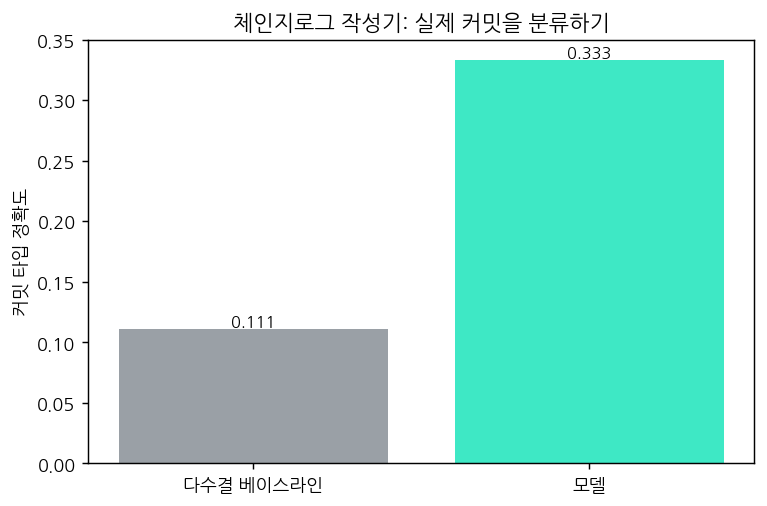

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/16_changelog.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/16_changelog.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (changelog-drafter: report-only, ~8134 tokens)


{'run_id': '2026-08-22T03:38:41Z',
 'pattern': 'changelog-drafter',
 'duration_s': 0.0,
 'items_found': 108,
 'actions_taken': 108,
 'escalations': 0,
 'tokens_estimate': 8134,
 'outcome': 'report-only'}

In [4]:
# ── 그림과 결과 저장 ─────────────────────────────────────────────
show.compare("분류: 모델 vs 다수결", maj_acc, acc)
plotting.ab_bar("16_changelog", ["다수결 베이스라인", "모델"], [maj_acc, acc],
                "커밋 타입 정확도", "체인지로그 작성기: 실제 커밋을 분류하기")

runlog.save_metrics("16_changelog", {"notebook": "16_changelog", "n": len(sample), "types": present_types,
                                     "accuracy": acc, "majority_accuracy": maj_acc, "macro_f1": macro_f1,
                                     # 한국어판 추가: 어느 백엔드의 수치인지 기록한다.
                                     # 모델이 바뀌면 위 세 값이 전부 바뀐다.
                                     "provider": llm.provider,
                                     "model": llm.model,
                                     # 한국어판 추가: 실측 데이터인지 합성 폴백인지 남긴다.
                                     # 이 한 줄이 없으면 나중에 results/ 를 뒤질 때
                                     # 원본 실측치와 스모크 테스트 수치가 구분되지 않는다.
                                     "data_source": DATA_SOURCE,
                                     "tokens": llm.usage.total_tokens})
# outcome="report-only": 초안까지만 만들고 게시하지 않았다는 사실을 로그에 못 박는다.
# escalations=0 인 이유는 이 루프가 아무것도 자동 실행하지 않아 넘길 것이 없기 때문이다.
runlog.log_run(pattern="changelog-drafter", duration_s=0, items_found=len(sample),
               actions_taken=len(sample), escalations=0, tokens_estimate=llm.usage.total_tokens,
               outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [5]:
# ── 위 수치에서 그대로 계산해 진술한다 (사람이 옮겨 적지 않는다) ──
show.head("이 실행이 실제로 보여 준 것")
print(f"실제 Vue 커밋 {len(sample)}건, {len(present_types)}개 타입에서 모델은 커밋 타입을")
print(f"정확도 {acc:.0%} 로 복원했고 (다수결 베이스라인 {maj_acc:.0%}, macro-F1 {macro_f1:.2f}),")
print("그 배치로 섹션이 나뉜 릴리스 노트를 초안했다.")
print()
print("=> 체인지로그 작성기는 병합된 작업을 분류하고 다듬은 노트를 제안한다. 게시 전에는")
print("   사람이 승인한다. 일부 타입(chore vs build vs ci)은 진짜로 모호하고, 그것이")
print("   자동 게시가 아니라 초안에서 멈추는 이유다.")
print()
# 데이터 출처를 결론과 함께 찍는다. 합성 폴백으로 돌았다면 위 수치는 원문과 다르다.
print(f"데이터 출처: {DATA_SOURCE}")


========================================= 이 실행이 실제로 보여 준 것 =========================================
실제 Vue 커밋 108건, 9개 타입에서 모델은 커밋 타입을
정확도 33% 로 복원했고 (다수결 베이스라인 11%, macro-F1 0.33),
그 배치로 섹션이 나뉜 릴리스 노트를 초안했다.

=> 체인지로그 작성기는 병합된 작업을 분류하고 다듬은 노트를 제안한다. 게시 전에는
   사람이 승인한다. 일부 타입(chore vs build vs ci)은 진짜로 모호하고, 그것이
   자동 게시가 아니라 초안에서 멈추는 이유다.

데이터 출처: synthetic-fallback
